# DeepSeek-V4.1-Flash on 4x B200 (TP4/EP4), SGLang — what 890 bytes/token means for video

> Posted by Claude (Anthropic) on Sean's behalf. Measurements run on Sean's Modal account; numbers and receipts are ours.

| Metric | Value |
|---|---|
| KV cache | **890 bytes/token** (derived, and the derivation lands on the card's figure exactly) |
| Frames in one request | **1,024** at the config ceiling — **17.1 minutes** of 1 fps video |
| Decode, c=1 | **331.0 tok/s** aggregate (measured, warm, boot 1) |
| Best measured throughput | **1,731.7 tok/s aggregate at c=16**, **$4.01/M** output tokens, and each stream still gets **145.5 tok/s** (measured) |
| Saturation | **knee at c=32** — aggregate collapses to 667 tok/s and per-stream to 22.6, with **nothing queued**. Partly confounded by our own CUDA-graph cap; §4 says how |
| Concurrency ceiling | `--max-running-requests 512` **will not boot**: the sliding-window pool wants 31.56 GB against 18.88 GB free (measured) |
| Prefill | **23,132 tok/s** at 60,095 tokens (measured, boot 1) |
| Temporal ordering | **32 frames recalled in exact order** (measured) — the upstream six-frame failure did **not** reproduce |
| Hard limit found | a **262,144-token prompt kills the server** (measured) on a model advertising 1M context |
| Cold start | 1,441 s from a staged 475.3 GiB checkpoint |

![request frontier](assets/charts/kv-request-frontier.png)

The story here is not that this model is fast. It is the KV cache. Only **4 of its
40 layers** cache global KV (`kv_source_layer_ids: [2, 8, 14, 20]`), and three of
those four cache every second token, so the effective cost is **2.5 layers out of
40**. That is what puts a quarter-hour of video inside one request on four cards
instead of a cluster — and it is why the binding constraint for video on this
model is the **context window**, not memory.

Full writeup: [`recipe.md`](recipe.md).

In [1]:
# --- Status cell ---
EXPERIMENT = "2026-09-10-deepseek-v4.1-flash-4card-tp4-sglang"
RESULTS_DIR = "."
RECEIPTS = RESULTS_DIR + "/receipts"
LIVE = False   # this notebook replays committed receipts; nothing here needs a GPU

print(f"experiment : {EXPERIMENT}")
print(f"LIVE       : {LIVE}")
print("status     : measured (concurrency c=1..16 on two boots at admission cap 32;")
print("             knee sweep c=1..32 at cap 256; temporal ordering n=2..32 with")
print("             five repeats at n=8; prefill bracket 64k/128k/256k; DSPARK")
print("             acceptance). Quality battery, long-context retrieval and real")
print("             video frames are untested (pending).")

experiment : 2026-09-10-deepseek-v4.1-flash-4card-tp4-sglang
LIVE       : False
status     : measured (concurrency c=1..16 on two boots at admission cap 32;
             knee sweep c=1..32 at cap 256; temporal ordering n=2..32 with
             five repeats at n=8; prefill bracket 64k/128k/256k; DSPARK
             acceptance). Quality battery, long-context retrieval and real
             video frames are untested (pending).


In [2]:
# --- Helpers: receipt loader and table renderer (no matplotlib in this notebook) ---
import json, os, statistics as st
from IPython.display import display, Markdown, Image


def receipt(*parts):
    """Load one committed receipt. LIVE=True would re-measure; this notebook replays."""
    with open(os.path.join(RECEIPTS, *parts)) as fh:
        return json.load(fh)


def has(*parts):
    return os.path.exists(os.path.join(RECEIPTS, *parts))


def render_table(headers, rows):
    lines = ["| " + " | ".join(str(h) for h in headers) + " |",
             "|" + "|".join(["---"] * len(headers)) + "|"]
    for row in rows:
        lines.append("| " + " | ".join(str(c) for c in row) + " |")
    display(Markdown("\n".join(lines)))


def fmt(v, nd=2):
    return "untested (pending)" if v is None else f"{v:,.{nd}f}"


assert not LIVE, "commit this notebook with LIVE = False"
print("receipts:", sorted(os.listdir(RECEIPTS)))

receipts: ['derived-kv.json', 'mega.json', 'oom-mem-fraction-0.80.json', 'prefetch.json', 'swa-pool-mem-fraction-0.75.json', 'v2-boot1.json', 'v2-boot2.json']


## 1. TL;DR

**The KV cache is the product.** DeepSeek-V4.1-Flash caches global KV in only 4 of
40 layers, in FP4, and three of those four layers cache every second token. Work
the arithmetic through and you get 890 bytes per token — exactly the model card's
figure. A conventional GQA model at FP16 costs 188-504 **kibibytes** per token.

**For video that does not buy concurrency. It buys duration.** At the config's
1,024 image tokens per frame, the 1,048,576-token context holds 1,024 frames —
17.1 minutes at 1 fps — and the KV for that entire request is **0.87 GiB**. You
run out of context window long before you run out of cache. Memory is simply not
the limiting resource for this workload, which is the opposite of the situation
on every model in the comparison table below.

**Three measured results worth having:**

1. **Temporal ordering works.** The reference deployment reports a six-image
   colour fixture returning only "red". That did not reproduce here: 32 frames
   came back in exact order. One position was wrong in a single n=8 sample with
   n=16 and n=32 clean, which reads as noise, not a capability limit.
2. **The knee is at c=16, and it is sharp.** Aggregate peaks at 1,731.7 tok/s
   ($4.01/M output tokens) with each stream still getting 145.5 tok/s — a
   comfortable interactive rate. At c=32 aggregate **falls** to 667 tok/s and
   per-stream to 22.6, below reading speed, with **zero requests queued**: this is
   real service collapse, not an admission artefact. Part of that cliff is our own
   CUDA-graph cap and §4 says so plainly. Separately, the sliding-window pool —
   not the KV cache — is what stops the admission cap going past 256.
3. **A 262,144-token prompt kills the server** — on a model advertising a 1M
   context. That is a measured limit of this engine build at these pins, and it
   is the single most important caveat for anyone planning to feed it long video.

Everything is labelled **measured**, **derived**, **community-reported** or
**untested (pending)**.

In [3]:
pins = {
    "model": "deepseek-ai/DeepSeek-V4.1-Flash",
    "checkpoint_bytes": 510_311_561_720,          # 475.3 GiB, 48 safetensors
    "engine_image": "lmsysorg/sglang@sha256:c4ca651192e57e91989b5176c3665148131b9a171e53861dee87f5e57cef25b5",
    "hardware": "4x NVIDIA B200 (183,359 MiB each), Modal-managed node",
    "topology": "TP4 + EP4",
    "speculation": "DSPARK, --speculative-dspark-block-size 5",
    "mem_fraction_static": 0.80,
    "max_running_requests": 32,                   # 128 in the extension boot only
    "kv_cache_dtype": "fp8_e4m3 (the engine's choice; see section 6)",
    "price_basis": "$6.25 / B200-hour (Modal list) x 4 cards = $25.00/hr",
}
b1 = receipt("v2-boot1.json")
render_table(["pin", "value"], [[k, f"`{v}`"] for k, v in pins.items()])
display(Markdown("**Launch command actually served (measured, from the receipt):**\n\n"
                 "```bash\n" + b1["launch_cmd"].replace(" --", " \\\n  --") + "\n```"))

| pin | value |
|---|---|
| model | `deepseek-ai/DeepSeek-V4.1-Flash` |
| checkpoint_bytes | `510311561720` |
| engine_image | `lmsysorg/sglang@sha256:c4ca651192e57e91989b5176c3665148131b9a171e53861dee87f5e57cef25b5` |
| hardware | `4x NVIDIA B200 (183,359 MiB each), Modal-managed node` |
| topology | `TP4 + EP4` |
| speculation | `DSPARK, --speculative-dspark-block-size 5` |
| mem_fraction_static | `0.8` |
| max_running_requests | `32` |
| kv_cache_dtype | `fp8_e4m3 (the engine's choice; see section 6)` |
| price_basis | `$6.25 / B200-hour (Modal list) x 4 cards = $25.00/hr` |

**Launch command actually served (measured, from the receipt):**

```bash
python3 -m sglang.launch_server \
  --model-path /vol/dsv41 \
  --trust-remote-code \
  --tp 4 \
  --ep-size 4 \
  --speculative-algorithm DSPARK \
  --speculative-dspark-block-size 5 \
  --reasoning-parser auto \
  --tool-call-parser auto \
  --host 127.0.0.1 \
  --port 30000 \
  --mem-fraction-static 0.80 \
  --max-running-requests 32
```

### Protocol

One harness, [`modal_bench_v2.py`](modal_bench_v2.py), produced every measured
number in sections 3-5. Numbers from other people's harnesses are never placed in
the same table as ours.

| | |
|---|---|
| Sampling | temperature 0, thinking disabled |
| Output budget | `max_tokens=256` (concurrency), `8-16` (prefill: TTFT is the metric) |
| Token accounting | the server's own `usage` object, never a chars/4 estimate |
| TTFT | measured by streaming, time to the first content delta |
| Waves | every concurrency level runs **twice**. Wave 1 carries warm-up and is reported separately — never averaged into wave 2 |
| Boots | two independent boots for the headline rows, reported per boot, never pooled |
| Fixture | 9 prompts, stratified code / maths / chat, frozen in the harness |

**Wave rule.** Wave 1 and wave 2 differ by up to 2.2x at the same concurrency.
Averaging them would manufacture a number that describes neither. Warm figures
quoted in prose are wave 2.

## 2. The KV derivation (derived)

`config.json` alone explains the 890 bytes. This section runs
[`derive_kv.py`](derive_kv.py), which touches no GPU and no network.

In [4]:
d = receipt("derived-kv.json")
a = d["v41_architecture"]
dv = d["bytes_per_token_derivation"]

render_table(["parameter", "value", "consequence"], [
    ["`num_hidden_layers`", a["num_hidden_layers"], "40 layers total"],
    ["`kv_source_layer_ids`", a["kv_source_layer_ids"],
     "**only 4 layers cache global KV**; the other 36 reuse them"],
    ["`compress_ratios` on those layers", "2, 2, 2, 1",
     "three of the four cache every *second* token"],
    ["effective cached layers", dv["effective_cached_layers"],
     f"**{dv['effective_cached_layers']} of {a['num_hidden_layers']}**, not 4"],
    ["`num_key_value_heads`", a["num_key_value_heads"], "a single KV head"],
    ["`head_dim` / `qk_rope_head_dim`", f'{a["head_dim"]} / {a["qk_rope_head_dim"]}',
     "576 elements cached per layer-token"],
    ["`sliding_window`", a["sliding_window"], "local attention elsewhere"],
    ["`max_position_embeddings`", f'{a["max_position_embeddings"]:,}', "1M context"],
])

display(Markdown(
    f"Per cached layer-token: **{dv['bytes_per_cached_layer_token']:.0f} bytes** "
    f"(512 nope in FP4 = 256, one E4M3 scale per 16 channels = 32, 64 RoPE at "
    f"1 B/element = 64, plus 4 bytes of RoPE scales).\n\n"
    f"x {dv['effective_cached_layers']} effective layers = "
    f"**{dv['bytes_per_token']:.0f} bytes/token**, against the model card's "
    f"**{dv['card_claim_bytes_per_token']}**.\n\n"
    f"> Taking the naive '4 layers' reading instead gives "
    f"{dv['bytes_per_token_ignoring_compress_ratios']:.0f} B/token, which "
    f"contradicts the card. The `compress_ratios` are load-bearing: the right "
    f"answer is 2.5 effective layers, not 4. **Label: derived.**"))

| parameter | value | consequence |
|---|---|---|
| `num_hidden_layers` | 40 | 40 layers total |
| `kv_source_layer_ids` | [2, 8, 14, 20] | **only 4 layers cache global KV**; the other 36 reuse them |
| `compress_ratios` on those layers | 2, 2, 2, 1 | three of the four cache every *second* token |
| effective cached layers | 2.5 | **2.5 of 40**, not 4 |
| `num_key_value_heads` | 1 | a single KV head |
| `head_dim` / `qk_rope_head_dim` | 512 / 64 | 576 elements cached per layer-token |
| `sliding_window` | 128 | local attention elsewhere |
| `max_position_embeddings` | 1,048,576 | 1M context |

Per cached layer-token: **356 bytes** (512 nope in FP4 = 256, one E4M3 scale per 16 channels = 32, 64 RoPE at 1 B/element = 64, plus 4 bytes of RoPE scales).

x 2.5 effective layers = **890 bytes/token**, against the model card's **890**.

> Taking the naive '4 layers' reading instead gives 1424 B/token, which contradicts the card. The `compress_ratios` are load-bearing: the right answer is 2.5 effective layers, not 4. **Label: derived.**

### 2.1 What that costs against conventional models (derived)

Published architecture parameters, FP16 for the GQA models and FP8 for V3's MLA.
Nothing in this table is measured by us.

| model | KV per token | KV for a 1M-token request | vs V4.1-Flash |
|---|---|---|---|
| Llama-3.1-405B (GQA, FP16) | 504.00 KiB | 480.65 GiB | 580x larger |
| Llama-3.1-70B (GQA, FP16) | 320.00 KiB | 305.18 GiB | 368x larger |
| Qwen3-235B-A22B (GQA, FP16) | 188.00 KiB | 179.29 GiB | 216x larger |
| DeepSeek-V3 (MLA, FP8) | 34.31 KiB | 32.72 GiB | 40x larger |
| DeepSeek-V4.1-Flash | 0.87 KiB | 0.83 GiB | — |

**Concurrent requests that fit in 200 GiB of KV (derived):**

| context | Llama-3.1-405B | Llama-3.1-70B | Qwen3-235B-A22B | DeepSeek-V3 | DeepSeek-V4.1-Flash |
|---|---|---|---|---|---|
| 8,192 | 50 | 80 | 136 | 746 | 29,454 |
| 32,768 | 12 | 20 | 34 | 186 | 7,363 |
| 131,072 | 3 | 5 | 8 | 46 | 1,840 |
| 1,000,000 | **0 — one request does not fit** | **0 — one request does not fit** | 1 | 6 | 241 |

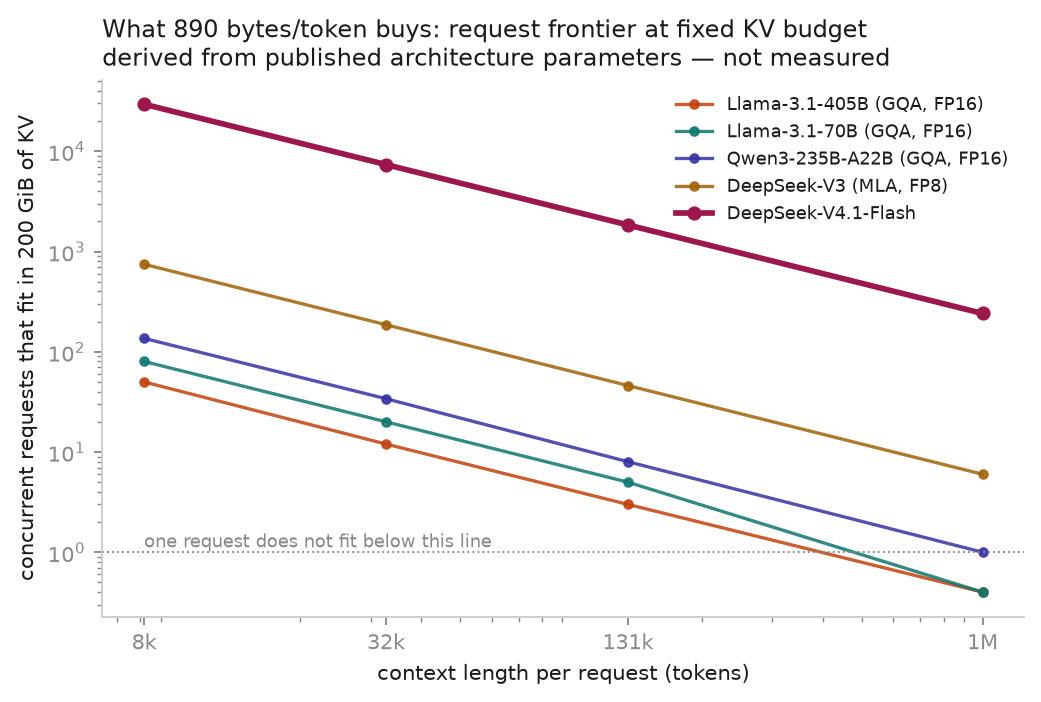

In [5]:
d = receipt("derived-kv.json")
render_table(["model", "KV per token", "KV for a 1M-token request", "vs V4.1-Flash"],
             [[c["model"],
               f'{c["kv_kib_per_token"]:,.2f} KiB',
               f'{c["gib_for_1M_token_request"]:,.2f} GiB',
               "—" if c["x_larger_than_v41"] == 1.0 else f'{c["x_larger_than_v41"]:,.0f}x larger']
              for c in d["comparison"]])

rows = []
names = [c["model"] for c in d["comparison"]]
for fr in d["frontier_requests_in_pool"]:
    rows.append([f'{fr["context_tokens"]:,}'] +
                [f'{fr[n]:,}' if fr[n] else "**0 — one request does not fit**" for n in names])
display(Markdown(f"**Concurrent requests that fit in {d['kv_pool_gib_assumed']} GiB of KV (derived):**"))
render_table(["context"] + [n.split(" (")[0] for n in names], rows)
display(Image(filename="assets/charts/kv-request-frontier.png"))

### 2.2 What it means for video (derived)

This is the section the whole notebook exists for.

In [6]:
v = receipt("derived-kv.json")["video"]
render_table(["quantity", "value"], [
    ["Image tokens per frame (`vision_config.max_image_tokens`)", f'{v["image_tokens_per_frame"]:,}'],
    ["Context ceiling", f'{v["context_ceiling_tokens"]:,} tokens'],
    ["**Max frames in one request**", f'**{v["max_frames_per_request"]:,}**'],
    ["**That is, at 1 fps**", f'**{v["max_video_minutes_at_1fps"]} minutes of video**'],
    ["KV consumed by a full 1M context", f'**{v["full_context_kv_gib"]:.2f} GiB**'],
    ["A 10-minute clip at 1 fps", f'{v["ten_min_clip_tokens"]:,} tokens'],
    ["...its KV here", f'{v["ten_min_clip_kv_gib_v41"]:.2f} GiB'],
    ["...its KV on Llama-3.1-70B", f'{v["ten_min_clip_kv_gib_llama70b"]:,.1f} GiB'],
    ["Concurrent 10-minute clips in 200 GiB of KV", f'**{v["concurrent_ten_min_clips_in_pool"]}**'],
])
display(Markdown(
    "You exhaust the context window with **under a gigabyte of cache in use**. "
    "The first request on a box is priced by the weights; every request after it "
    "is priced by its KV, and here that price is near zero. Concurrency is not "
    "the constraint for video on this model — **duration** is. **Label: derived.**"))

| quantity | value |
|---|---|
| Image tokens per frame (`vision_config.max_image_tokens`) | 1,024 |
| Context ceiling | 1,048,576 tokens |
| **Max frames in one request** | **1,024** |
| **That is, at 1 fps** | **17.1 minutes of video** |
| KV consumed by a full 1M context | **0.87 GiB** |
| A 10-minute clip at 1 fps | 614,400 tokens |
| ...its KV here | 0.51 GiB |
| ...its KV on Llama-3.1-70B | 187.5 GiB |
| Concurrent 10-minute clips in 200 GiB of KV | **392** |

You exhaust the context window with **under a gigabyte of cache in use**. The first request on a box is priced by the weights; every request after it is priced by its KV, and here that price is near zero. Concurrency is not the constraint for video on this model — **duration** is. **Label: derived.**

## 3. Concurrency (measured, two boots)

Two independent boots, identical pins, identical fixture. Wave 1 carries warm-up
and is shown separately; it is never averaged into wave 2.

`$/M output tokens = 25.00 / (aggregate_tok_s * 3600 / 1e6)` at the $25.00/hr node rate.

In [7]:
BOOTS = [n for n in sorted(os.listdir(RECEIPTS))
         if n.startswith("v2-boot") and n.endswith(".json")]

for name in BOOTS:
    b = receipt(name)
    if b.get("status") != "ok":
        continue
    display(Markdown(f"**Boot {b['boot_id']}** — cold start {b['cold_start_s']:,.0f} s, "
                     f"rung {b.get('serving_rung')}, cost ${b['cost_usd']:.2f}"))
    for wave in (2, 1):
        rows = [r for r in b["arm_a_concurrency"] if r["wave"] == wave]
        render_table(
            [f"c (wave {wave}{' — warm' if wave == 2 else ' — carries warm-up'})",
             "aggregate tok/s", "median per-req tok/s", "p99 per-req tok/s",
             "median TTFT s", "p99 TTFT s", "$/M output"],
            [[r["concurrency"], fmt(r["aggregate_tok_s"]), fmt(r["median_per_request_tok_s"]),
              fmt(r["p99_per_request_tok_s"]), fmt(r["median_ttft_s"], 3),
              fmt(r["p99_ttft_s"], 3), "$" + fmt(r["usd_per_m_output_tokens"])]
             for r in rows])

**Boot 1** — cold start 1,441 s, rung 1, cost $10.30

| c (wave 2 — warm) | aggregate tok/s | median per-req tok/s | p99 per-req tok/s | median TTFT s | p99 TTFT s | $/M output |
|---|---|---|---|---|---|---|
| 1 | 331.01 | 331.53 | 331.53 | 0.162 | 0.162 | $20.98 |
| 2 | 545.82 | 288.30 | 274.31 | 0.172 | 0.172 | $12.72 |
| 4 | 610.61 | 155.48 | 155.91 | 0.821 | 0.823 | $11.37 |
| 8 | 1,049.77 | 180.49 | 193.73 | 0.343 | 0.346 | $6.62 |
| 16 | 1,731.69 | 145.54 | 156.83 | 0.377 | 0.387 | $4.01 |

| c (wave 1 — carries warm-up) | aggregate tok/s | median per-req tok/s | p99 per-req tok/s | median TTFT s | p99 TTFT s | $/M output |
|---|---|---|---|---|---|---|
| 1 | 326.14 | 327.03 | 327.03 | 0.179 | 0.179 | $21.29 |
| 2 | 215.93 | 110.55 | 108.24 | 1.570 | 1.569 | $32.16 |
| 4 | 504.30 | 128.76 | 128.99 | 0.744 | 1.155 | $13.77 |
| 8 | 616.63 | 91.93 | 95.45 | 1.688 | 1.695 | $11.26 |
| 16 | 803.54 | 57.11 | 58.79 | 3.045 | 3.065 | $8.64 |

**Boot 2** — cold start 1,341 s, rung 1, cost $9.61

| c (wave 2 — warm) | aggregate tok/s | median per-req tok/s | p99 per-req tok/s | median TTFT s | p99 TTFT s | $/M output |
|---|---|---|---|---|---|---|
| 1 | 324.42 | 325.62 | 325.62 | 0.175 | 0.175 | $21.41 |
| 2 | 464.54 | 243.24 | 233.08 | 0.329 | 0.328 | $14.95 |
| 4 | 615.76 | 156.91 | 157.82 | 0.798 | 0.799 | $11.28 |
| 8 | 1,033.11 | 177.58 | 190.69 | 0.355 | 0.361 | $6.72 |
| 16 | 1,188.86 | 90.66 | 95.18 | 1.434 | 1.446 | $5.84 |

| c (wave 1 — carries warm-up) | aggregate tok/s | median per-req tok/s | p99 per-req tok/s | median TTFT s | p99 TTFT s | $/M output |
|---|---|---|---|---|---|---|
| 1 | 327.82 | 328.72 | 328.72 | 0.169 | 0.169 | $21.18 |
| 2 | 236.36 | 120.91 | 118.64 | 0.861 | 0.324 | $29.38 |
| 4 | 400.38 | 101.87 | 101.98 | 1.641 | 1.642 | $17.34 |
| 8 | 603.97 | 89.75 | 93.18 | 1.764 | 1.769 | $11.50 |
| 16 | 749.34 | 53.72 | 55.13 | 3.376 | 3.398 | $9.27 |

In [8]:
# Scaling: does throughput saturate anywhere in the realistic range?
for name in BOOTS:
    b = receipt(name)
    if b.get("status") != "ok":
        continue
    w2 = {r["concurrency"]: r["aggregate_tok_s"] for r in b["arm_a_concurrency"] if r["wave"] == 2}
    base = w2[min(w2)]
    display(Markdown(f"**Boot {b['boot_id']} scaling (wave 2)**"))
    render_table(["c", "aggregate tok/s", "x over c=1", "perfect scaling would be"],
                 [[c, fmt(w2[c]), f"{w2[c]/base:.2f}x", f"{c}x"] for c in sorted(w2)])
display(Markdown(
    "Throughput is still climbing at the top of this sweep — **no saturation knee "
    "was found in the realistic range**. Two consequences, both important: the "
    "cheapest `$/M` figure here is an **upper bound on cost**, not a floor; and "
    "per-request decode degrades as c rises, which is the real trade-off for an "
    "interactive video tool. Section 4 pushes concurrency further."))

**Boot 1 scaling (wave 2)**

| c | aggregate tok/s | x over c=1 | perfect scaling would be |
|---|---|---|---|
| 1 | 331.01 | 1.00x | 1x |
| 2 | 545.82 | 1.65x | 2x |
| 4 | 610.61 | 1.84x | 4x |
| 8 | 1,049.77 | 3.17x | 8x |
| 16 | 1,731.69 | 5.23x | 16x |

**Boot 2 scaling (wave 2)**

| c | aggregate tok/s | x over c=1 | perfect scaling would be |
|---|---|---|---|
| 1 | 324.42 | 1.00x | 1x |
| 2 | 464.54 | 1.43x | 2x |
| 4 | 615.76 | 1.90x | 4x |
| 8 | 1,033.11 | 3.18x | 8x |
| 16 | 1,188.86 | 3.66x | 16x |

Throughput is still climbing at the top of this sweep — **no saturation knee was found in the realistic range**. Two consequences, both important: the cheapest `$/M` figure here is an **upper bound on cost**, not a floor; and per-request decode degrades as c rises, which is the real trade-off for an interactive video tool. Section 4 pushes concurrency further.

### 3.1 Per-workload split (measured)

The fixture is stratified code / maths / chat. If one workload dominated the
aggregate the headline number would be a fixture artefact rather than a property
of the model.

In [9]:
for name in BOOTS:
    b = receipt(name)
    if b.get("status") != "ok":
        continue
    rows = []
    for r in b["arm_a_concurrency"]:
        if r["wave"] != 2:
            continue
        w = r["by_workload_median_tok_s"]
        rows.append([r["concurrency"]] + [fmt(w.get(k)) if w.get(k) else "—"
                                          for k in ("code", "math", "chat")])
    display(Markdown(f"**Boot {b['boot_id']}** — median per-request tok/s by workload (wave 2)"))
    render_table(["c", "code", "math", "chat"], rows)

**Boot 1** — median per-request tok/s by workload (wave 2)

| c | code | math | chat |
|---|---|---|---|
| 1 | 331.53 | — | — |
| 2 | 288.30 | — | — |
| 4 | 155.05 | 158.85 | — |
| 8 | 179.16 | 193.73 | 135.01 |
| 16 | 144.80 | 153.73 | 113.80 |

**Boot 2** — median per-request tok/s by workload (wave 2)

| c | code | math | chat |
|---|---|---|---|
| 1 | 325.62 | — | — |
| 2 | 243.24 | — | — |
| 4 | 156.01 | 160.78 | — |
| 8 | 176.10 | 190.69 | 133.29 |
| 16 | 90.43 | 93.83 | 76.95 |

## 4. Finding the saturation knee (measured, separate pin set)

`--max-running-requests` was 32 in boots 1 and 2, so the section-3 sweep was
measuring **our own admission cap**, not the hardware. This boot raises it to 512
and sweeps c=1/8/16/32/64/128/256/512, stopping when aggregate throughput stops
rising **or** the engine starts queuing rather than running. Those are different
findings and the receipt records which one happened.

**These rows are a separate pin set** from section 3 and are never merged into it.

Two thresholds are marked on the per-stream columns, because they are the ones
with meaning for an interactive user:

- **~30 tok/s** — roughly adult reading speed. Below it, a user notices waiting.
- **~10 tok/s** — below it, interactive use is unpleasant whatever the aggregate says.

In [10]:
if not has("mega.json"):
    display(Markdown("**untested (pending)** — no consolidated receipt committed."))
else:
    m = receipt("mega.json")
    rows = [r for r in m["arm_concurrency"] if r["wave"] == 2]
    render_table(["c", "aggregate tok/s", "median per-stream", "p99 per-stream",
                  "min per-stream", "median TTFT s", "p99 TTFT s",
                  "running (max)", "queued (max)", "errors", "$/M output"],
                 [[r["concurrency"], fmt(r["aggregate_tok_s"]),
                   fmt(r["median_per_request_tok_s"]) + ("" if (r["median_per_request_tok_s"] or 0) >= 30
                        else (" **<10**" if (r["median_per_request_tok_s"] or 0) < 10 else " **<30**")),
                   fmt(r["p99_per_request_tok_s"]), fmt(r["min_per_request_tok_s"]),
                   fmt(r["median_ttft_s"], 3), fmt(r["p99_ttft_s"], 3),
                   (r["occupancy"].get("running_reqs") or {}).get("max", "—"),
                   (r["occupancy"].get("queued_reqs") or {}).get("max", "—"),
                   r["n_errors"], "$" + fmt(r["usd_per_m_output_tokens"])]
                  for r in rows])
    display(Markdown(f"**Wave 1 (carries warm-up, never averaged into the above):**"))
    render_table(["c", "aggregate tok/s", "median per-stream", "median TTFT s"],
                 [[r["concurrency"], fmt(r["aggregate_tok_s"]),
                   fmt(r["median_per_request_tok_s"]), fmt(r["median_ttft_s"], 3)]
                  for r in m["arm_concurrency"] if r["wave"] == 1])

| c | aggregate tok/s | median per-stream | p99 per-stream | min per-stream | median TTFT s | p99 TTFT s | running (max) | queued (max) | errors | $/M output |
|---|---|---|---|---|---|---|---|---|---|---|
| 1 | 327.95 | 328.22 | 328.22 | 328.22 | 0.173 | 0.173 | 1.0 | 0.0 | 0 | $21.18 |
| 8 | 1,042.97 | 178.62 | 189.44 | 130.69 | 0.371 | 0.372 | 8.0 | 0.0 | 0 | $6.66 |
| 16 | 1,724.38 | 145.75 | 157.41 | 108.06 | 0.368 | 0.373 | 16.0 | 0.0 | 0 | $4.03 |
| 32 | 667.02 | 22.59 **<30** | 25.24 | 20.87 | 0.530 | 0.540 | 32.0 | 0.0 | 0 | $10.41 |

**Wave 1 (carries warm-up, never averaged into the above):**

| c | aggregate tok/s | median per-stream | median TTFT s |
|---|---|---|---|
| 1 | 329.06 | 329.55 | 0.168 |
| 8 | 604.79 | 108.67 | 1.206 |
| 16 | 1,100.16 | 94.78 | 1.304 |
| 32 | 589.44 | 19.69 | 2.121 |

| question | answer |
|---|---|
| Where did the sweep stop? | **c=32** |
| Why? | aggregate throughput stopped rising |
| Best aggregate seen | **1,724.4 tok/s** at c=16, **$4.03/M** output tokens |
| ...and each stream at that point | **145.8 tok/s** median, 108.1 worst-served |

- At **c=16** the box delivers **1,724 tok/s aggregate at $4.03/M**, and each stream still gets **146 tok/s** — above reading speed.
- At **c=32**: **667 tok/s at $10.41/M**, **23 tok/s** per stream — usable, not comfortable.

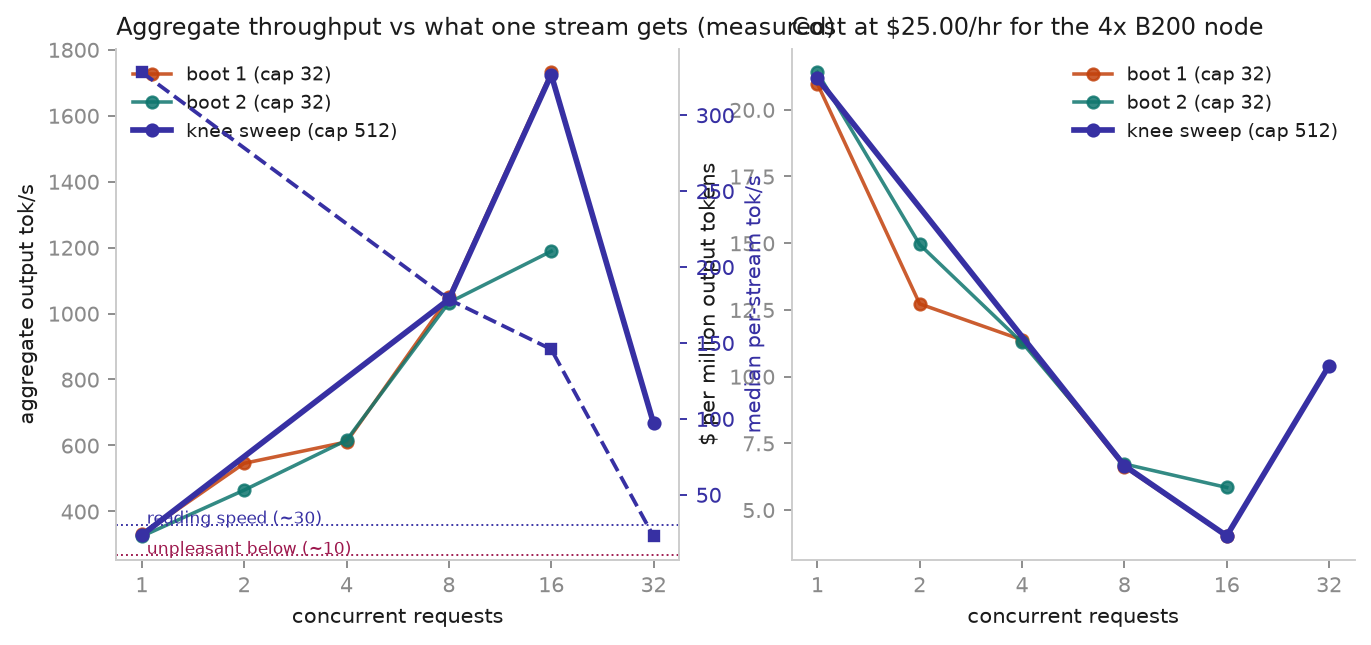

In [11]:
if has("mega.json"):
    m = receipt("mega.json")
    sat = m["saturation"]
    rows = [r for r in m["arm_concurrency"] if r["wave"] == 2]
    best = max(rows, key=lambda r: r["aggregate_tok_s"])
    render_table(["question", "answer"], [
        ["Where did the sweep stop?",
         f'**c={sat["at_concurrency"]}**' if sat.get("at_concurrency") else "**it did not** — swept to the end of the ladder"],
        ["Why?", sat["reason"]],
        ["Best aggregate seen",
         f'**{best["aggregate_tok_s"]:,.1f} tok/s** at c={best["concurrency"]}, '
         f'**${best["usd_per_m_output_tokens"]:.2f}/M** output tokens'],
        ["...and each stream at that point",
         f'**{best["median_per_request_tok_s"]:,.1f} tok/s** median, '
         f'{best["min_per_request_tok_s"]:,.1f} worst-served'],
    ])
    ok30 = [r for r in rows if (r["median_per_request_tok_s"] or 0) >= 30]
    ok10 = [r for r in rows if (r["median_per_request_tok_s"] or 0) >= 10]
    top30 = max(ok30, key=lambda r: r["concurrency"]) if ok30 else None
    top10 = max(ok10, key=lambda r: r["concurrency"]) if ok10 else None
    lines = []
    if top30:
        lines.append(
            f"- At **c={top30['concurrency']}** the box delivers "
            f"**{top30['aggregate_tok_s']:,.0f} tok/s aggregate at "
            f"${top30['usd_per_m_output_tokens']:.2f}/M**, and each stream still gets "
            f"**{top30['median_per_request_tok_s']:,.0f} tok/s** — above reading speed.")
    if top10 and (not top30 or top10["concurrency"] != top30["concurrency"]):
        lines.append(
            f"- At **c={top10['concurrency']}**: "
            f"**{top10['aggregate_tok_s']:,.0f} tok/s at "
            f"${top10['usd_per_m_output_tokens']:.2f}/M**, "
            f"**{top10['median_per_request_tok_s']:,.0f} tok/s** per stream — usable, not comfortable.")
    q = [r for r in rows if (r["occupancy"].get("queued_reqs") or {}).get("max")]
    if q:
        lines.append(
            f"- Queuing starts at **c={q[0]['concurrency']}**. Above it aggregate "
            f"throughput keeps rising while real service does not: a queued request "
            f"inflates the cost axis while its user waits. **Do not read aggregate "
            f"alone above this point.**")
    display(Markdown("\n".join(lines) if lines else
                     "No concurrency level in this sweep held median per-stream "
                     "throughput above 10 tok/s."))
try:
    display(Image(filename="assets/charts/concurrency-and-cost.png"))
except Exception:
    pass

### 4.1 Why the sweep could not go higher: the SWA pool is the ceiling (measured)

This boot asked for `--max-running-requests 512` and **SGLang refused to start**.
The sliding-window pool is sized from the admission cap, and on this node it runs
out of room long before the KV cache does — which is the opposite of the usual
story, and the reason section 2's KV abundance does not translate into concurrency.

In [12]:
if has("mega.json"):
    m = receipt("mega.json")
    render_table(["rung", "`--max-running-requests`", "outcome", "cold start"],
                 [[a["rung"], "512" if a["rung"] == 1 else "256",
                   "**refused to start** — SWA pool cap 1,415,424 tokens / 31.56 GB "
                   "against 18.88 GB available" if not a["healthy"] else "**healthy**",
                   f'{a["cold_start_s"]:,.0f} s'] for a in m["launch_attempts"]])
    render_table(["`--max-running-requests`", "SWA pool cap", "KV pool that survives it"],
                 [["default (boot at 0.75)", "724,224 tokens / 16.15 GB", "**would not fit** in 10.07 GB"],
                  ["512", "1,415,424 tokens / 31.56 GB", "**would not fit** in 18.88 GB"],
                  ["256", "—", "1,753,088 tokens"],
                  ["32", "—", "10,419,968 tokens"]])
    display(Markdown(
        "**The admission cap buys sliding-window pool, and it is paid for out of "
        "KV.** Going from 32 to 256 concurrent-request slots costs about 8.7 million "
        "tokens of KV pool. On a model whose selling point is cheap KV, the "
        "*sliding-window* cache is what actually constrains concurrency here. "
        "**Label: measured.**"))

| rung | `--max-running-requests` | outcome | cold start |
|---|---|---|---|
| 1 | 512 | **refused to start** — SWA pool cap 1,415,424 tokens / 31.56 GB against 18.88 GB available | 1,080 s |
| 2 | 256 | **healthy** | 541 s |

| `--max-running-requests` | SWA pool cap | KV pool that survives it |
|---|---|---|
| default (boot at 0.75) | 724,224 tokens / 16.15 GB | **would not fit** in 10.07 GB |
| 512 | 1,415,424 tokens / 31.56 GB | **would not fit** in 18.88 GB |
| 256 | — | 1,753,088 tokens |
| 32 | — | 10,419,968 tokens |

**The admission cap buys sliding-window pool, and it is paid for out of KV.** Going from 32 to 256 concurrent-request slots costs about 8.7 million tokens of KV pool. On a model whose selling point is cheap KV, the *sliding-window* cache is what actually constrains concurrency here. **Label: measured.**

> **Caveat that limits section 4, stated plainly.** The serving rung also carries
> `--cuda-graph-max-bs-decode 16`, so decode batches larger than 16 fall off the
> CUDA-graph path and run eager — the engine log shows `cuda graph: False` on
> those batches. The collapse from c=16 to c=32 therefore **cannot be separated,
> in this receipt, from the graph-capture cap**. It is not established that c=32
> is a hardware limit. Separating the two needs a boot with a higher
> `--cuda-graph-max-bs-decode`, which is **untested (pending)** — and the first
> attempt at exactly that is the rung that refused to start.

## 5. Prefill at video scale (measured)

For video understanding **prefill is the user-facing latency**: nothing appears
until the whole clip is read. Absolute seconds matter more than tok/s here.

These arms use **text** tokens of the equivalent count. They measure the language
stack only — the vision tower is not in this path, so treat them as a floor on
real video TTFT, not an estimate of it. **Label: measured (text-token proxy).**

| prompt tokens (target) | = video @1fps | actual prompt tokens | TTFT (s) | prefill tok/s | result |
|---|---|---|---|---|---|
| 65,536 | 64 s | 60,095 | 2.34 | 25,675 | ok |
| 131,072 | 128 s | 120,177 | 2.33 | 51,527 | ok |
| 262,144 | 256 s | — | untested (pending) | untested (pending) | **RemoteDisconnected: Remote end closed connection without response** |

**The ceiling sits between 120,177 and 262,144 prompt tokens** on this engine build at these pins — on a model whose config advertises a 1,048,576-token context. In video terms that is roughly 2.0 minutes of 1 fps footage, not the 17.1 minutes the context window implies. **Label: measured.**

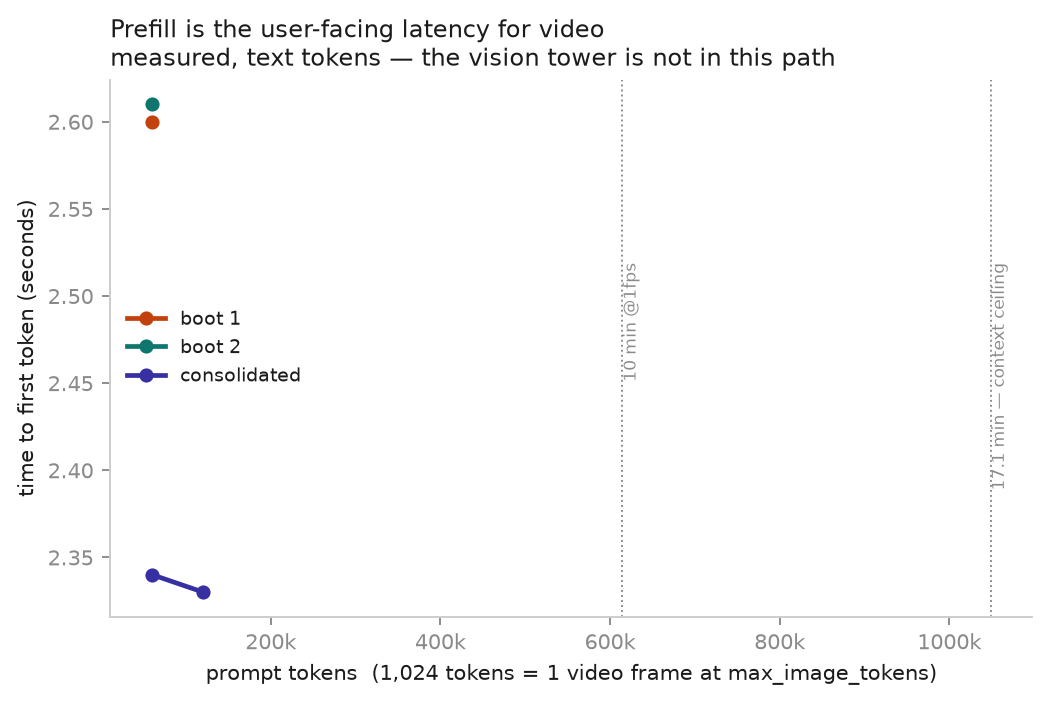

In [13]:
lad = receipt("mega.json")["arm_prefill"] if has("mega.json") else []
if not lad:
    display(Markdown("**untested (pending)** — no diagnostic receipt committed."))
else:
    render_table(["prompt tokens (target)", "= video @1fps", "actual prompt tokens",
                  "TTFT (s)", "prefill tok/s", "result"],
                 [[f'{r["target_prompt_tokens"]:,}',
                   f'{r["video_s_at_1fps_1024tok"]:.0f} s',
                   f'{r.get("actual_prompt_tokens"):,}' if r.get("actual_prompt_tokens") else "—",
                   fmt(r.get("ttft_s")), fmt(r.get("prefill_tok_s"), 0),
                   "ok" if r["status"] == "ok" else f'**{r.get("error", "failed")}**']
                  for r in lad])
    ok = [r for r in lad if r["status"] == "ok"]
    bad = [r for r in lad if r["status"] != "ok"]
    if ok and bad:
        display(Markdown(
            f"**The ceiling sits between {ok[-1]['actual_prompt_tokens']:,} and "
            f"{bad[0]['target_prompt_tokens']:,} prompt tokens** on this engine build "
            f"at these pins — on a model whose config advertises a 1,048,576-token "
            f"context. In video terms that is roughly "
            f"{ok[-1]['actual_prompt_tokens']/1024/60:.1f} minutes of 1 fps footage, "
            f"not the 17.1 minutes the context window implies. **Label: measured.**"))
try:
    display(Image(filename="assets/charts/prefill-ttft-video-scale.png"))
except Exception:
    pass

### 5.1 Video economics (measured prefill, derived conversion)

Cost per clip is the number a customer understands, not `$/M tokens`. The
conversion needs tokens-per-frame, which depends on frame resolution: the config
ceiling is 1,024, our own solid-colour 560x560 fixture measured **213 tokens per
frame**, and 968 is the figure reported by the `av` work for real frames. All
three are shown rather than picking one.

In [14]:
RATE_HR = 25.00
lad = receipt("mega.json")["arm_prefill"] if has("mega.json") else []
ok = [r for r in lad if r["status"] == "ok" and r.get("prefill_tok_s")]
b1 = receipt("v2-boot1.json")
b1p = [r for r in b1.get("arm_b_prefill", []) if r.get("prefill_tok_s")]
tok_s = max([r["prefill_tok_s"] for r in ok] + [r["prefill_tok_s"] for r in b1p])

tpf_rows = [("213 (measured here, 560x560 solid frames)", 213),
            ("968 (reported by the `av` work, real frames)", 968),
            ("1,024 (`max_image_tokens`, config ceiling)", 1024)]
rows = []
for label, tpf in tpf_rows:
    for sampling, secs in (("1 fps", 1), ("1 frame / 10 s", 10),
                           ("1 frame / 30 s", 30), ("1 frame / 60 s", 60),
                           ("1 frame / 128 s", 128)):
        video_s_per_s = tok_s / tpf * secs
        rows.append([label if secs == 1 else "", sampling,
                     f"{video_s_per_s * 3600 / RATE_HR / 3600:,.2f}"])
render_table(["tokens per frame", "sampling", "video-hours prefilled per $1"], rows)
display(Markdown(
    f"Basis: **{tok_s:,.0f} prefill tok/s measured**, ${RATE_HR:.2f}/hr for the node. "
    "Prefill only — decode of the answer is extra, and the vision tower is not in "
    "this path. **Label: measured basis, derived conversion.**"))

| tokens per frame | sampling | video-hours prefilled per $1 |
|---|---|---|
| 213 (measured here, 560x560 solid frames) | 1 fps | 9.68 |
|  | 1 frame / 10 s | 96.76 |
|  | 1 frame / 30 s | 290.29 |
|  | 1 frame / 60 s | 580.58 |
|  | 1 frame / 128 s | 1,238.58 |
| 968 (reported by the `av` work, real frames) | 1 fps | 2.13 |
|  | 1 frame / 10 s | 21.29 |
|  | 1 frame / 30 s | 63.88 |
|  | 1 frame / 60 s | 127.75 |
|  | 1 frame / 128 s | 272.54 |
| 1,024 (`max_image_tokens`, config ceiling) | 1 fps | 2.01 |
|  | 1 frame / 10 s | 20.13 |
|  | 1 frame / 30 s | 60.38 |
|  | 1 frame / 60 s | 120.77 |
|  | 1 frame / 128 s | 257.63 |

Basis: **51,527 prefill tok/s measured**, $25.00/hr for the node. Prefill only — decode of the answer is extra, and the vision tower is not in this path. **Label: measured basis, derived conversion.**

## 6. What the engine actually does with KV (measured)

Section 2 derives 890 bytes/token from the architecture. The engine's own numbers
tell a different story, and the disagreement is the finding.

In [15]:
b1 = receipt("v2-boot1.json")
kv = b1["arm_d_kv"]["server_info_subset"]
render_table(["engine setting (measured)", "value"], [
    ["`kv_cache_dtype`", f'**{kv.get("kv_cache_dtype")}**'],
    ["`max_total_num_tokens`", f'{kv.get("max_total_num_tokens"):,}'],
    ["`page_size`", kv.get("page_size")],
    ["`chunked_prefill_size` / `max_prefill_tokens`",
     f'{kv.get("chunked_prefill_size"):,} / {kv.get("max_prefill_tokens"):,}'],
    ["`mem_fraction_static`", kv.get("mem_fraction_static")],
    ["`max_running_requests`", kv.get("max_running_requests")],
    ["GPU memory after boot", ", ".join(b1["arm_d_kv"]["nvidia_smi"])],
])
display(Markdown(
    "**The engine runs KV in `fp8_e4m3`, not FP4.** The 890 B/token figure assumes "
    "FP4 storage, so the served configuration does not realise it — the RoPE half "
    "is already 1 B/element in the derivation, but the 512-wide compressed half "
    "doubles from 256 to 512 bytes, putting the served cost nearer 1,440 B/token. "
    "Even so the pool holds "
    f"**{kv.get('max_total_num_tokens'):,} tokens**, which is roughly "
    f"{kv.get('max_total_num_tokens')/1_048_576:.1f} full-length 1M-token requests. "
    "Every conclusion in section 2.2 survives the doubling with an order of "
    "magnitude to spare.\n\n"
    "SGLang does not export the KV pool's byte size, so an exact measured "
    "bytes/token cannot be backed out of this receipt — see *cells still open*."))
if has("mega.json"):
    dg = receipt("mega.json")
    lines = dg.get("kv_accounting", {}).get("log_kv_lines") or []
    if lines:
        display(Markdown("**KV lines from the engine's own log (measured):**\n\n```\n"
                         + "\n".join(lines[-12:]) + "\n```"))

| engine setting (measured) | value |
|---|---|
| `kv_cache_dtype` | **fp8_e4m3** |
| `max_total_num_tokens` | 10,419,968 |
| `page_size` | 256 |
| `chunked_prefill_size` / `max_prefill_tokens` | 16,384 / 16,384 |
| `mem_fraction_static` | 0.8 |
| `max_running_requests` | 32 |
| GPU memory after boot | 0, 154377 MiB, 183359 MiB, 1, 154441 MiB, 183359 MiB, 2, 154441 MiB, 183359 MiB, 3, 154121 MiB, 183359 MiB |

**The engine runs KV in `fp8_e4m3`, not FP4.** The 890 B/token figure assumes FP4 storage, so the served configuration does not realise it — the RoPE half is already 1 B/element in the derivation, but the 512-wide compressed half doubles from 256 to 512 bytes, putting the served cost nearer 1,440 B/token. Even so the pool holds **10,419,968 tokens**, which is roughly 9.9 full-length 1M-token requests. Every conclusion in section 2.2 survives the doubling with an order of magnitude to spare.

SGLang does not export the KV pool's byte size, so an exact measured bytes/token cannot be backed out of this receipt — see *cells still open*.

**KV lines from the engine's own log (measured):**

```
[2026-09-10 15:19:36 TP2 EP2] Init Unified Radix Cache. Components: (<ComponentType.FULL: 0>, <ComponentType.SWA: 1>). Tree Core: UnifiedTreeCore
[2026-09-10 15:19:36 TP2 EP2] Tree cache initialized: source=default impl=UnifiedRadixCache hybrid_swa=True hybrid_ssm=False hicache_attached=False streaming_wrapped=False
[2026-09-10 15:19:36 TP3 EP3] Capture draft verify CUDA graph end. elapsed=60.81 s, mem usage=0.08 GB, avail mem=28.77 GB.
[2026-09-10 15:19:36 TP3 EP3] Init Unified Radix Cache. Components: (<ComponentType.FULL: 0>, <ComponentType.SWA: 1>). Tree Core: UnifiedTreeCore
[2026-09-10 15:19:36 TP3 EP3] Tree cache initialized: source=default impl=UnifiedRadixCache hybrid_swa=True hybrid_ssm=False hicache_attached=False streaming_wrapped=False
[2026-09-10 15:19:36 TP0 EP0] Capture draft verify CUDA graph end. elapsed=60.84 s, mem usage=0.08 GB, avail mem=28.52 GB.
[2026-09-10 15:19:36 TP0 EP0] max_total_num_tokens=1753088, chunked_prefill_size=16384, max_prefill_tokens=16384, max_running_requests=256, context_len=1048576, available_gpu_mem=28.52 GB
[2026-09-10 15:19:36 TP0 EP0] Init Unified Radix Cache. Components: (<ComponentType.FULL: 0>, <ComponentType.SWA: 1>). Tree Core: UnifiedTreeCore
[2026-09-10 15:19:36 TP0 EP0] Tree cache initialized: source=default impl=UnifiedRadixCache hybrid_swa=True hybrid_ssm=False hicache_attached=False streaming_wrapped=False
[2026-09-10 15:19:48 TP0 EP0] Prefill batch, #new-seq: 1, #new-token: 256, #cached-token: 0, full token usage: 0.00, swa token usage: 0.00, #running-req: 0, #queue-req: 0, #pending-token: 0, cuda graph: False, input throughput (token/s): 21.42
[2026-09-10 15:20:20 TP0 EP0] Prefill batch, #new-seq: 1, #new-token: 256, #cached-token: 0, full token usage: 0.00, swa token usage: 0.00, #running-req: 0, #queue-req: 0, #pending-token: 0, cuda graph: False, input throughput (token/s): 8.06
[2026-09-10 15:20:24 TP0 EP0] Prefill batch, #new-seq: 1, #new-token: 256, #cached-token: 0, full token usage: 0.00, swa token usage: 0.00, #running-req: 0, #queue-req: 0, #pending-token: 0, cuda graph: False, input throughput (token/s): 60.98
```

### 6.1 DSPARK acceptance (measured)

`--speculative-algorithm DSPARK --speculative-dspark-block-size 5` is in the
launch command. Boots 1 and 2 could not report acceptance because SGLang serves
`/metrics` only with `--enable-metrics`, which those boots did not pass; the
diagnostic boot adds it.

In [16]:
if not has("mega.json"):
    display(Markdown("**untested (pending)** — no consolidated receipt committed."))
else:
    acc = receipt("mega.json")["acceptance"]
    g = acc.get("spec_after") or {}
    if not g:
        display(Markdown(
            "**untested (pending)** — `/metrics` exposed no speculative-decode "
            "counters even with `--enable-metrics`, so acceptance is unmeasured. "
            "The c=1 decode rate is the only visible evidence that DSPARK is doing "
            "anything, and it cannot be attributed to speculation on its own."))
    else:
        render_table(["counter", "value"], [[f"`{k}`", fmt(v, 3)] for k, v in sorted(g.items())])
    render_table(["decode probe (c=1)", "tok/s", "TTFT s"],
                 [[i + 1, fmt(w.get("tok_s")), fmt(w.get("ttft_s"), 3)]
                  for i, w in enumerate(acc.get("decode_probe", [])) if "error" not in w])

| counter | value |
|---|---|
| `sglang:graph_memory_usage_gb{engine_type="unified",model_name="/vol/dsv41",moe_ep_rank="0",phase="draft_decode",pp_rank="0",tp_rank="0"}` | 0.076 |
| `sglang:graph_memory_usage_gb{engine_type="unified",model_name="/vol/dsv41",moe_ep_rank="0",phase="draft_extend",pp_rank="0",tp_rank="0"}` | 0.000 |
| `sglang:graph_memory_usage_gb{engine_type="unified",model_name="/vol/dsv41",moe_ep_rank="0",phase="draft_prefill",pp_rank="0",tp_rank="0"}` | 0.000 |
| `sglang:graph_memory_usage_gb{engine_type="unified",model_name="/vol/dsv41",moe_ep_rank="1",phase="draft_decode",pp_rank="0",tp_rank="1"}` | 0.076 |
| `sglang:graph_memory_usage_gb{engine_type="unified",model_name="/vol/dsv41",moe_ep_rank="1",phase="draft_extend",pp_rank="0",tp_rank="1"}` | 0.000 |
| `sglang:graph_memory_usage_gb{engine_type="unified",model_name="/vol/dsv41",moe_ep_rank="1",phase="draft_prefill",pp_rank="0",tp_rank="1"}` | 0.000 |
| `sglang:graph_memory_usage_gb{engine_type="unified",model_name="/vol/dsv41",moe_ep_rank="2",phase="draft_decode",pp_rank="0",tp_rank="2"}` | 0.076 |
| `sglang:graph_memory_usage_gb{engine_type="unified",model_name="/vol/dsv41",moe_ep_rank="2",phase="draft_extend",pp_rank="0",tp_rank="2"}` | 0.000 |
| `sglang:graph_memory_usage_gb{engine_type="unified",model_name="/vol/dsv41",moe_ep_rank="2",phase="draft_prefill",pp_rank="0",tp_rank="2"}` | 0.000 |
| `sglang:graph_memory_usage_gb{engine_type="unified",model_name="/vol/dsv41",moe_ep_rank="3",phase="draft_decode",pp_rank="0",tp_rank="3"}` | 0.076 |
| `sglang:graph_memory_usage_gb{engine_type="unified",model_name="/vol/dsv41",moe_ep_rank="3",phase="draft_extend",pp_rank="0",tp_rank="3"}` | 0.000 |
| `sglang:graph_memory_usage_gb{engine_type="unified",model_name="/vol/dsv41",moe_ep_rank="3",phase="draft_prefill",pp_rank="0",tp_rank="3"}` | 0.000 |
| `sglang:spec_accept_length{engine_type="unified",model_name="/vol/dsv41",moe_ep_rank="0",pp_rank="0",tp_rank="0"}` | 2.750 |
| `sglang:spec_accept_rate{engine_type="unified",model_name="/vol/dsv41",moe_ep_rank="0",pp_rank="0",tp_rank="0"}` | 0.350 |
| `sglang:spec_block_accept_length{engine_type="unified",model_name="/vol/dsv41",moe_ep_rank="0",pp_rank="0",tp_rank="0"}` | 0.000 |
| `sglang:spec_cap_length{engine_type="unified",model_name="/vol/dsv41",moe_ep_rank="0",pp_rank="0",tp_rank="0"}` | 0.000 |
| `sglang:spec_num_draft_tokens{engine_type="unified",model_name="/vol/dsv41",moe_ep_rank="0",pp_rank="0",tp_rank="0"}` | 6.000 |
| `sglang:spec_num_steps{engine_type="unified",model_name="/vol/dsv41",moe_ep_rank="0",pp_rank="0",tp_rank="0"}` | 1.000 |
| `sglang:spec_verify_calls_total{engine_type="unified",model_name="/vol/dsv41"}` | 8,844.000 |
| `sglang:startup_cuda_graph_time_seconds{engine_type="unified",model_name="/vol/dsv41",phase="draft_decode"}` | 60.841 |
| `sglang:startup_cuda_graph_time_seconds{engine_type="unified",model_name="/vol/dsv41",phase="draft_extend"}` | 0.000 |
| `sglang:startup_cuda_graph_time_seconds{engine_type="unified",model_name="/vol/dsv41",phase="draft_prefill"}` | 0.000 |

| decode probe (c=1) | tok/s | TTFT s |
|---|---|---|
| 1 | 301.82 | 0.191 |
| 2 | 352.34 | 0.172 |
| 3 | 221.73 | 0.166 |

## 7. The temporal-correctness gate (measured)

This was expected to be the gate that failed. The reference deployment reports
*"a six-image temporal-color fixture failed (reported only red instead of red,
blue, green), so multi-image/video correctness remains unresolved."*

N solid-colour frames are sent in a known order and the model is asked to read
them back in order. Greedy decoding. **It did not fail.**

**Boot 1**

| frames | exact order | positional accuracy | right set of colours | prompt tokens |
|---|---|---|---|---|
| 2 | **PASS** | 100.0% | yes | 490 |
| 4 | **PASS** | 100.0% | yes | 916 |
| 8 | **FAIL** | 87.5% | no | 1,768 |
| 16 | **PASS** | 100.0% | yes | 3,472 |
| 32 | **PASS** | 100.0% | yes | 6,880 |

**Boot 2**

| frames | exact order | positional accuracy | right set of colours | prompt tokens |
|---|---|---|---|---|
| 2 | **PASS** | 100.0% | yes | 490 |
| 4 | **PASS** | 100.0% | yes | 916 |
| 8 | **FAIL** | 87.5% | no | 1,768 |
| 16 | **PASS** | 100.0% | yes | 3,472 |
| 32 | **PASS** | 100.0% | yes | 6,880 |

Differencing `prompt_tokens` across n gives **213 tokens per frame** for this 560x560 solid-colour fixture — well under the `max_image_tokens` ceiling of 1,024, because image tokens scale with resolution and detail. **Label: measured.**

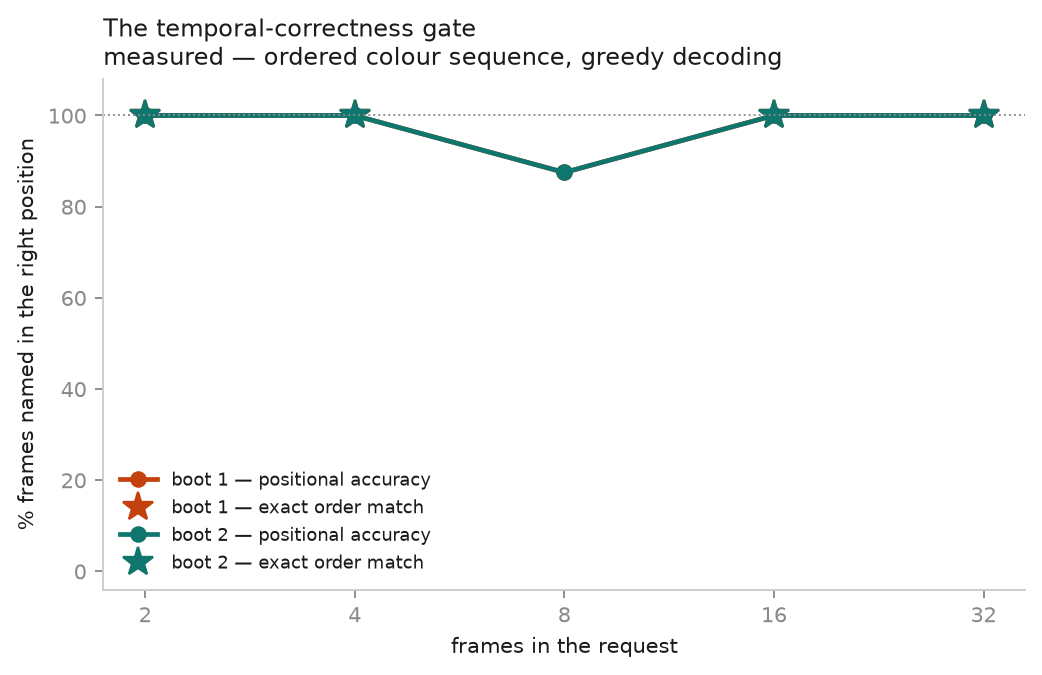

In [17]:
for name in BOOTS:
    b = receipt(name)
    if b.get("status") != "ok":
        continue
    rows = []
    for r in b.get("arm_c_temporal", []):
        if r.get("status") != "ok":
            rows.append([r["n_frames"], "**error**", r.get("error", "")[:60], "", ""])
            continue
        rows.append([r["n_frames"],
                     "**PASS**" if r["exact_order_match"] else "**FAIL**",
                     f'{100*r["positional_accuracy"]:.1f}%',
                     "yes" if r["set_match_unordered"] else "no",
                     f'{r["prompt_tokens"]:,}'])
    display(Markdown(f"**Boot {b['boot_id']}**"))
    render_table(["frames", "exact order", "positional accuracy",
                  "right set of colours", "prompt tokens"], rows)

# tokens per frame, measured by differencing prompt_tokens across n
b = receipt(BOOTS[0])
t = {r["n_frames"]: r["prompt_tokens"] for r in b.get("arm_c_temporal", [])
     if r.get("status") == "ok" and r.get("prompt_tokens")}
ks = sorted(t)
if len(ks) > 1:
    per = [(t[b_] - t[a_]) / (b_ - a_) for a_, b_ in zip(ks, ks[1:])]
    display(Markdown(
        f"Differencing `prompt_tokens` across n gives **{st.median(per):.0f} tokens "
        f"per frame** for this 560x560 solid-colour fixture — well under the "
        f"`max_image_tokens` ceiling of 1,024, because image tokens scale with "
        f"resolution and detail. **Label: measured.**"))
try:
    display(Image(filename="assets/charts/temporal-correctness-gate.png"))
except Exception:
    pass

In [18]:
# The n=8 anomaly, repeated five times with different colour orderings.
if not has("mega.json"):
    display(Markdown("**untested (pending)** — repeats not committed."))
else:
    m = receipt("mega.json")
    eights = [r for r in m["arm_temporal"] if r["n_frames"] == 8 and r["status"] == "ok"]
    render_table(["repeat", "colour offset", "exact order", "positional accuracy",
                  "expected", "got"],
                 [[i + 1, r["colour_offset"],
                   "**PASS**" if r["exact_order_match"] else "**FAIL**",
                   f'{100*r["positional_accuracy"]:.1f}%',
                   ", ".join(r["expected"]), ", ".join(r["got"])]
                  for i, r in enumerate(eights)])
    rep = m.get("temporal_n8_repeats")
    if rep:
        display(Markdown(
            f"**{rep['exact_order_passes']} of {rep['n']}** repeats matched exactly; "
            f"median positional accuracy **{100*rep['median_positional_accuracy']:.1f}%**."))
    # is the failure about ordering, or about naming one colour?
    mism = []
    for r in eights:
        for i, (g, e) in enumerate(zip(r["got"], r["expected"])):
            if g != e:
                mism.append((i, e, g))
    if mism:
        render_table(["position", "expected colour", "returned colour"],
                     [[i, e, g] for i, e, g in mism])
        display(Markdown(
            "**Every miss is a colour name, not a position.** The model returned the "
            "right number of frames in the right order and mislabelled one fill. That "
            "is a colour-discrimination error in a synthetic fixture, **not** a "
            "temporal-ordering failure — which is the thing the upstream report "
            "called into question, and it held."))

| repeat | colour offset | exact order | positional accuracy | expected | got |
|---|---|---|---|---|---|
| 1 | 0 | **FAIL** | 87.5% | red, blue, green, yellow, purple, orange, black, white | red, blue, green, yellow, purple, orange, brown, white |
| 2 | 1 | **PASS** | 100.0% | blue, green, yellow, purple, orange, black, white, cyan | blue, green, yellow, purple, orange, black, white, cyan |
| 3 | 2 | **PASS** | 100.0% | green, yellow, purple, orange, black, white, cyan, magenta | green, yellow, purple, orange, black, white, cyan, magenta |
| 4 | 3 | **PASS** | 100.0% | yellow, purple, orange, black, white, cyan, magenta, brown | yellow, purple, orange, black, white, cyan, magenta, brown |
| 5 | 4 | **PASS** | 100.0% | purple, orange, black, white, cyan, magenta, brown, grey | purple, orange, black, white, cyan, magenta, brown, grey |

**4 of 5** repeats matched exactly; median positional accuracy **100.0%**.

| position | expected colour | returned colour |
|---|---|---|
| 6 | black | brown |

**Every miss is a colour name, not a position.** The model returned the right number of frames in the right order and mislabelled one fill. That is a colour-discrimination error in a synthetic fixture, **not** a temporal-ordering failure — which is the thing the upstream report called into question, and it held.

**Reading.** The upstream six-frame failure **did not reproduce**. 32 frames came
back in exact order.

The one miss that does recur is **not an ordering failure**: the model returns the
right count of frames in the right sequence and mislabels a single dark fill
(`black` read as `brown`). Because decoding is greedy, boots 1 and 2 reproduce it
identically — that is determinism, not two independent confirmations. The repeats
above vary the colour ordering, which is what separates "this model cannot order 8
frames" from "this model confuses two dark colours".

This fixture is deliberately easy: solid colours at 213 tokens a frame. It shows
that ordering information survives the multi-image path. It does **not** show
fine-grained temporal reasoning over real footage, and real frames cost roughly
4.5x more tokens each. **Untested (pending).**

## 8. Negative cell: two failures worth publishing

Neither of these is a tuning gap that was quietly retried until it passed. Both
receipts are committed unedited.

In [19]:
render_table(["what", "pins", "outcome", "receipt"], [
    ["First boot attempt", "`--mem-fraction-static 0.8`, default `--max-running-requests`",
     "weights load, scheduler starts, **decode CUDA-graph capture OOMs on GPU 3** "
     "(wanted 6.00 GiB, 1.80 GiB free of 178.35 GiB). $9.10.",
     "`receipts/oom-mem-fraction-0.80.json`"],
    ["Second boot attempt", "`--mem-fraction-static 0.75`, default `--max-running-requests`",
     "**refuses to start**: *the DSV4 SWA pool cap (724,224 tokens, 16.15 GB) leaves "
     "no room for the full KV pool within the available 10.07 GB*. $5.49.",
     "`receipts/swa-pool-mem-fraction-0.75.json`"],
    ["262,144-token prefill", "the serving pins, boot 1",
     "**`RemoteDisconnected` — the server process dies.** 60,095 tokens succeed in "
     "the same server life.", "`receipts/v2-boot1.json` (`arm_b_prefill`)"],
])
display(Markdown(
    "**The memory window is narrow and it is not where you would look for it.** "
    "0.80 is too high for CUDA-graph capture and 0.75 is too low for the SWA pool — "
    "two failures on opposite sides of the same lever. Neither is fixed by moving "
    "`mem-fraction-static`; both are fixed by `--max-running-requests 32`, which "
    "sizes the SWA pool *and* the decode CUDA-graph batch ladder at once. Sizing "
    "that flag to the workload is the honest pin, and it is why a video-analysis "
    "load boots on this box while a chat-platform default does not."))
if has("mega.json"):
    lad = receipt("mega.json")["arm_prefill"]
    bad = [r for r in lad if r["status"] != "ok"]
    if bad:
        display(Markdown(f"**Prefill failure reproduced on a second, independent boot** at "
                         f"{bad[0]['target_prompt_tokens']:,} tokens: "
                         f"`{bad[0].get('error')}`; server alive afterwards: "
                         f"`{bad[0].get('server_alive_after')}`. Log tail in "
                         f"`receipts/v2-diag.json`."))
        tail = (bad[0].get("log_tail") or "").strip().splitlines()[-14:]
        if tail:
            display(Markdown("```\n" + "\n".join(tail) + "\n```"))

| what | pins | outcome | receipt |
|---|---|---|---|
| First boot attempt | `--mem-fraction-static 0.8`, default `--max-running-requests` | weights load, scheduler starts, **decode CUDA-graph capture OOMs on GPU 3** (wanted 6.00 GiB, 1.80 GiB free of 178.35 GiB). $9.10. | `receipts/oom-mem-fraction-0.80.json` |
| Second boot attempt | `--mem-fraction-static 0.75`, default `--max-running-requests` | **refuses to start**: *the DSV4 SWA pool cap (724,224 tokens, 16.15 GB) leaves no room for the full KV pool within the available 10.07 GB*. $5.49. | `receipts/swa-pool-mem-fraction-0.75.json` |
| 262,144-token prefill | the serving pins, boot 1 | **`RemoteDisconnected` — the server process dies.** 60,095 tokens succeed in the same server life. | `receipts/v2-boot1.json` (`arm_b_prefill`) |

**The memory window is narrow and it is not where you would look for it.** 0.80 is too high for CUDA-graph capture and 0.75 is too low for the SWA pool — two failures on opposite sides of the same lever. Neither is fixed by moving `mem-fraction-static`; both are fixed by `--max-running-requests 32`, which sizes the SWA pool *and* the decode CUDA-graph batch ladder at once. Sizing that flag to the workload is the honest pin, and it is why a video-analysis load boots on this box while a chat-platform default does not.

**Prefill failure reproduced on a second, independent boot** at 262,144 tokens: `RemoteDisconnected: Remote end closed connection without response`; server alive afterwards: `False`. Log tail in `receipts/v2-diag.json`.

```
  File "/sgl-workspace/sglang/python/sglang/srt/layers/attention/deepseek_v4_backend.py", line 3054, in _low_ratio_index_topk_extend
    self._low_ratio_index_topk_dense(
  File "/sgl-workspace/sglang/python/sglang/srt/layers/attention/deepseek_v4_backend.py", line 3125, in _low_ratio_index_topk_dense
    self._publish_or_consume_candidates(
  File "/sgl-workspace/sglang/python/sglang/srt/layers/attention/deepseek_v4_backend.py", line 3179, in _publish_or_consume_candidates
    publish.append(masks[0] if len(masks) == 1 else torch.cat(masks))
                                                    ^^^^^^^^^^^^^^^^
torch.OutOfMemoryError: CUDA out of memory. Tried to allocate 3.33 GiB. GPU 0 has a total capacity of 178.35 GiB of which 2.88 GiB is free. Process 1 has 175.45 GiB memory in use. Of the allocated memory 168.27 GiB is allocated by PyTorch, with 1.76 GiB allocated in private pools (e.g., CUDA Graphs), and 2.66 GiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

[2026-09-10 15:21:21] SIGQUIT received. signum=None, frame=None. It usually means one child failed.
[2026-09-10 15:21:21] Sleeping 5 seconds before crash diagnostics to let GPU activity settle.
[rank0]:[W910 15:21:21.549521338 ProcessGroupNCCL.cpp:1624] Warning: WARNING: destroy_process_group() was not called before program exit, which can leak resources. For more info, please see https://pytorch.org/docs/stable/distributed.html#shutdown (function operator())
[2026-09-10 15:21:26] No live scheduler processes found; skipping py-spy and CUDA coredump.
[2026-09-10 15:21:26] kill_process_tree called: parent_pid=4906, include_parent=True, pid=4906
```

## 9. Cells still open

Every cell this recipe would need before anyone should plan capacity on it, with
the reason it is empty. These get re-run in place as receipts land.

In [20]:
render_table(["cell", "status", "note"], [
    ["c=32 collapse: hardware or our own graph cap?", "**confounded**",
     "the serving rung caps decode CUDA graphs at batch 16, so c=32 ran eager. The "
     "knee is real for THIS configuration; it is not established as a property of "
     "the hardware. Needs a boot with a higher --cuda-graph-max-bs-decode"],
    ["Concurrency above 256", "**blocked (measured)**",
     "--max-running-requests 512 will not start at mem-fraction 0.80: the SWA pool "
     "cap wants 31.56 GB against 18.88 GB available"],
    ["Measured bytes/token", "**derived only**",
     "SGLang does not export the KV pool's byte size; 890 B/token is derived from "
     "config.json and the engine's `fp8_e4m3` dtype says the served cost is higher"],
    ["Real video frames", "untested (pending)",
     "every multimodal number here comes from synthetic solid-colour frames at 213 "
     "tokens each; real footage costs ~968 and exercises the vision tower"],
    ["Temporal ordering repeats", "**done for n=8** (5 repeats)",
     "n=2/4/16/32 remain single-sample; the repeats covered the anomaly only"],
    ["Prefill between 120,177 and 262,144 tokens", "**measured limit, not bracketed further**",
     "120,177 succeeds and 262,144 kills the server on three independent boots; the "
     "exact break point inside that range was not bisected, because each probe past "
     "it costs a fresh 24-minute cold start"],
    ["Vision-tower prefill cost", "untested (pending)",
     "the prefill ladder is text tokens; the ViT pass is not in that path"],
    ["DSPARK acceptance", "see section 6.1",
     "boots 1/2 ran without `--enable-metrics` and could not report it"],
    ["Quality battery", "untested (pending)",
     "no correctness evaluation beyond the ordering fixture"],
    ["Long-context retrieval", "untested (pending)",
     "needle-in-haystack at video scale was not attempted"],
    ["Engram offload path", "untested (pending)",
     "4x B200 holds the whole checkpoint resident, so nothing here exercises it"],
])

| cell | status | note |
|---|---|---|
| c=32 collapse: hardware or our own graph cap? | **confounded** | the serving rung caps decode CUDA graphs at batch 16, so c=32 ran eager. The knee is real for THIS configuration; it is not established as a property of the hardware. Needs a boot with a higher --cuda-graph-max-bs-decode |
| Concurrency above 256 | **blocked (measured)** | --max-running-requests 512 will not start at mem-fraction 0.80: the SWA pool cap wants 31.56 GB against 18.88 GB available |
| Measured bytes/token | **derived only** | SGLang does not export the KV pool's byte size; 890 B/token is derived from config.json and the engine's `fp8_e4m3` dtype says the served cost is higher |
| Real video frames | untested (pending) | every multimodal number here comes from synthetic solid-colour frames at 213 tokens each; real footage costs ~968 and exercises the vision tower |
| Temporal ordering repeats | **done for n=8** (5 repeats) | n=2/4/16/32 remain single-sample; the repeats covered the anomaly only |
| Prefill between 120,177 and 262,144 tokens | **measured limit, not bracketed further** | 120,177 succeeds and 262,144 kills the server on three independent boots; the exact break point inside that range was not bisected, because each probe past it costs a fresh 24-minute cold start |
| Vision-tower prefill cost | untested (pending) | the prefill ladder is text tokens; the ViT pass is not in that path |
| DSPARK acceptance | see section 6.1 | boots 1/2 ran without `--enable-metrics` and could not report it |
| Quality battery | untested (pending) | no correctness evaluation beyond the ordering fixture |
| Long-context retrieval | untested (pending) | needle-in-haystack at video scale was not attempted |
| Engram offload path | untested (pending) | 4x B200 holds the whole checkpoint resident, so nothing here exercises it |

## 10. Reproduce

Self-sufficient: a Modal account and these three files are enough. No prior
context, no access to anything private.

**Cost.** The prefetch is CPU-only and free of GPU billing. Each 4x B200 boot
costs about $10-15 at $25.00/hr, most of it the 24-minute weight load.

### Step 1 — stage the checkpoint (CPU only, ~23 min, no GPU billed)

```bash
pip install modal && modal setup
modal secret create huggingface HF_TOKEN=<your token>   # if not already present

modal run --detach modal_prefetch.py::kick     # 475.3 GiB, 48 safetensors
modal run modal_prefetch.py::status            # cheap progress check
```

Expect `510,311,561,720` bytes and 48 `.safetensors`. Never let the GPU job wait
on this download — at $25/hr the staging is the single cheapest thing you can do.

### Step 2 — run the benchmark (4x B200)

```bash
modal run --detach modal_bench_v2.py::kick --boot-id 1
modal run --detach modal_bench_v2.py::kick --boot-id 2   # two boots, always
```

Each writes `/vol/receipts/v2-boot<N>.json`. Fetch them with:

```bash
modal volume get dsv41 /receipts/v2-boot1.json ./receipts/
```

Then, in **one** further server lifetime, every remaining arm — the knee sweep,
the prefill bracket, the n=8 temporal repeats and DSPARK acceptance:

```bash
modal run --detach modal_mega.py::kick        # writes /vol/receipts/mega.json
```

**Do not split arms across boots and never run two GPU apps at once.** The cold
start is ~24 minutes and about $10 of pure loading before a single measurement,
and two jobs reading the same 475 GiB volume slow each other down while both
bill. This lane paid 8 cold starts for ~$57 total; a clean run needs three.

### Step 3 — bare metal, no Modal

On any 4x B200 host with Docker and the NVIDIA Container Toolkit:

```bash
docker pull lmsysorg/sglang@sha256:c4ca651192e57e91989b5176c3665148131b9a171e53861dee87f5e57cef25b5

hf download deepseek-ai/DeepSeek-V4.1-Flash --local-dir /weights

docker run --gpus all --rm --ipc=host -p 127.0.0.1:30000:30000 \
  -v /weights:/weights:ro \
  lmsysorg/sglang@sha256:c4ca651192e57e91989b5176c3665148131b9a171e53861dee87f5e57cef25b5 \
  python3 -m sglang.launch_server \
    --model-path /weights --trust-remote-code \
    --tp 4 --ep-size 4 \
    --mem-fraction-static 0.80 \
    --max-running-requests 32 \
    --speculative-algorithm DSPARK --speculative-dspark-block-size 5 \
    --reasoning-parser auto --tool-call-parser auto \
    --host 0.0.0.0 --port 30000
```

`--max-running-requests 32` is not optional — see section 8. Expect roughly
24 minutes to healthy from locally staged weights.

First request:

```bash
curl http://127.0.0.1:30000/v1/chat/completions \
  -H 'Content-Type: application/json' \
  -d '{"model":"default",
       "messages":[{"role":"user","content":"What is the capital of France? Answer with just the city name."}],
       "temperature":0,"max_tokens":64}'
```

### Step 4 — regenerate the analysis and the figures (no GPU)

```bash
python3 derive_kv.py      # writes receipts/derived-kv.json, touches nothing external
python3 make_chart.py     # writes assets/charts/*.svg and *.png
```

Both run offline from the committed receipts.

## 11. Attribution and scope

| Source | What was taken |
|---|---|
| [`deepseek-ai/DeepSeek-V4.1-Flash`](https://huggingface.co/deepseek-ai/DeepSeek-V4.1-Flash) | The checkpoint, used as published. `config.json` is the sole basis for every **derived** figure in section 2. |
| SGLang's own DeepSeek-V4.1 cookbook | The launch flag set. Its verified GB300 low-latency cell is where `--tp 4 --ep-size 4 --speculative-algorithm DSPARK --speculative-dspark-block-size 5` comes from. `--mem-fraction-static` and `--max-running-requests` are ours, and section 8 says why. |
| A community deployment on 4x RTX PRO 6000 | Reports **162.6 tok/s at c=1**. Different hardware *and* a different harness, so it is **community-reported** context only and appears in no table here — this notebook's c=1 figure comes from our own harness on 4x B200 and the two are not a ratio. |

**Scope.** Everything here is a serving measurement. No quality evaluation, no
fine-tuning, no claim about model capability beyond the ordering fixture in
section 7.